Importing modules

In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from utils import get_selectedfeats_sarcasm, predict_classes_train, predict_classes_test
from utils import plot_clusters, plot_pca_matches
from utils import evaluate_from_confusion, get_filenames_fromfolder
from utils import samples_by_label_pair
from utils import plot_gndvspred, pick_random_per_pair

Setting up parameters

In [2]:
SEED = 1
np.random.seed(SEED)

Setting up directories

In [3]:
#----Parent directories----
dataset_parent_dir = '/projectnb/lejlab2/Sara/Second Project/kazuyas-data-project'
csvfiles_parent_dir = ''
figures_parent_dir = ''
textresults_parent_dir = ''

#----Folders---
# Raw data folder
raw_folder_name = 'dataset'
raw_folder_dir = os.path.join(dataset_parent_dir, raw_folder_name)

# Folder with per-sample sarcasm feature files
sarcasm_features_folder_name = f'{raw_folder_name}_sarcasm_features'
sarcasm_features_dir = os.path.join(dataset_parent_dir, sarcasm_features_folder_name)

# Count available samples based on feature files
print("Total number of data samples is:",
      len(get_filenames_fromfolder(sarcasm_features_dir, file_format="_features.csv")))

# Folder for CSV files
csvfiles_folder_name = 'csv_files'
csvfiles_folder_dir = os.path.join(csvfiles_parent_dir, csvfiles_folder_name)


# Folder for text results
textresults_folder_name = 'text_results'
textresults_folder_dir = os.path.join(textresults_parent_dir, textresults_folder_name)

#----Directories for metadata and txt files---

# Path to metadata CSV file
metadata_features_csv_dir  = os.path.join(csvfiles_folder_dir, 'metadata_features.csv')  

# Txts
PC_train_txt_dir = f'{textresults_folder_dir}/PC_train.txt'
PC_test_txt_dir = f'{textresults_folder_dir}/PC_test.txt'


Total number of data samples is: 1827


Setting up test and train

In [4]:
# Load metadata
df = pd.read_csv(metadata_features_csv_dir)

# Separate train and test samples
df_train = df[df["split"] == "train"].copy()
df_test  = df[df["split"] == "test"].copy()

# Train set: names, predictions and principal components of features
train_names = df_train['name'].to_list()
train_pred = df_train['group_pred'].to_numpy()
train_features_pca = np.loadtxt( PC_train_txt_dir )

# Test set: names + ground-truth labels + low-org indices
test_names  = df_test['name'].to_list()
test_labels = df_test['group_gnd'].to_numpy()
test_pred = df_test['group_pred'].to_numpy()
test_features_pca = np.loadtxt( PC_test_txt_dir )

# Results

Clusters: test and train

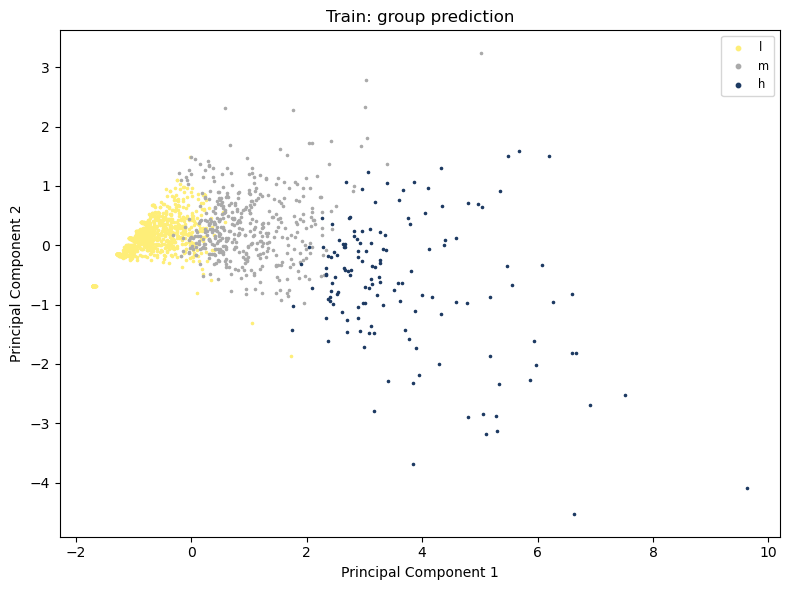

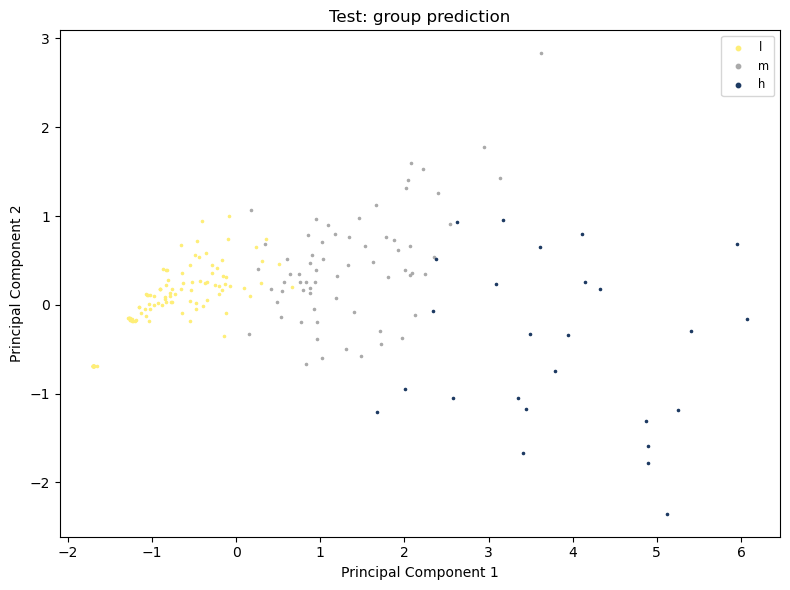

In [5]:
plot_clusters( train_features_pca,  train_pred, title = 'Train: group prediction')
plot_clusters( test_features_pca,  test_pred, title = 'Test: group prediction')

Mismatches: test

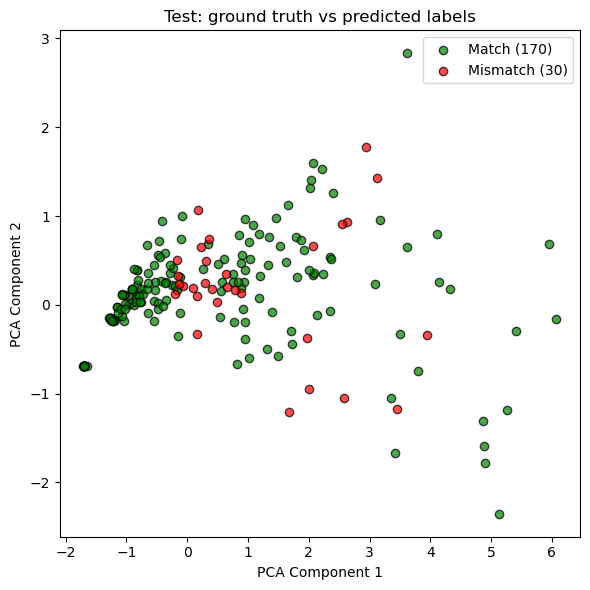

In [6]:
plot_pca_matches( test_features_pca, np.array( test_labels ), test_pred, title="Test: ground truth vs predicted labels")

Confusion matrix: test


For test metrics are:
  Accuracy: 0.850
  Macro precision: 0.826  |  Macro recall: 0.828
  Per-class precision: [0.888 0.821 0.769]
  Per-class recall:    [0.931 0.753 0.800]
Saved figure: confusion matrix, test


<Figure size 640x480 with 0 Axes>

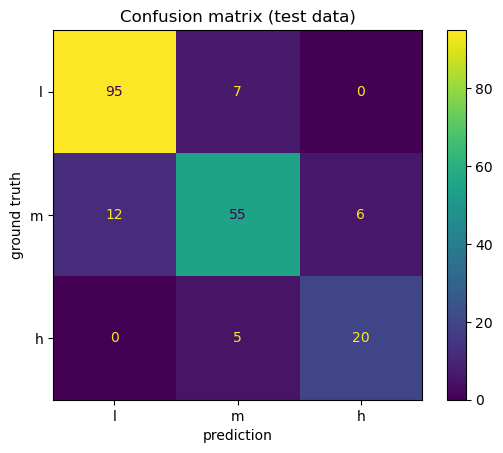

In [7]:
cm_test = confusion_matrix(test_labels, test_pred, labels=[0, 1, 2])
_, _, _ = evaluate_from_confusion( cm_test, title = 'test')

class_names = ['l', 'm', 'h']
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=class_names)
plt.figure()
disp.plot()
disp.ax_.set(xlabel='prediction', ylabel='ground truth')
plt.title("Confusion matrix (test data)")
print( 'Saved figure: confusion matrix, test')

Plotting a random sample from each case in the confusion matrix: test

No samples for (0.0, 2.0) key
No samples for (2.0, 0.0) key


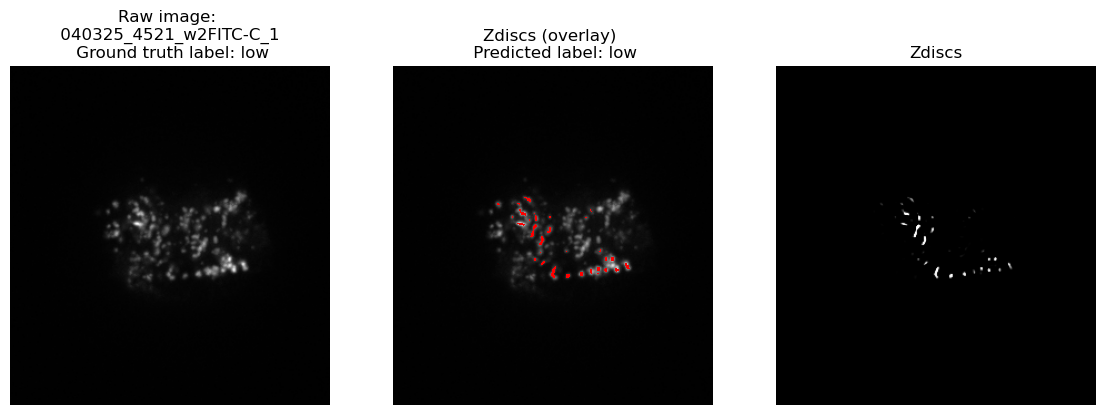

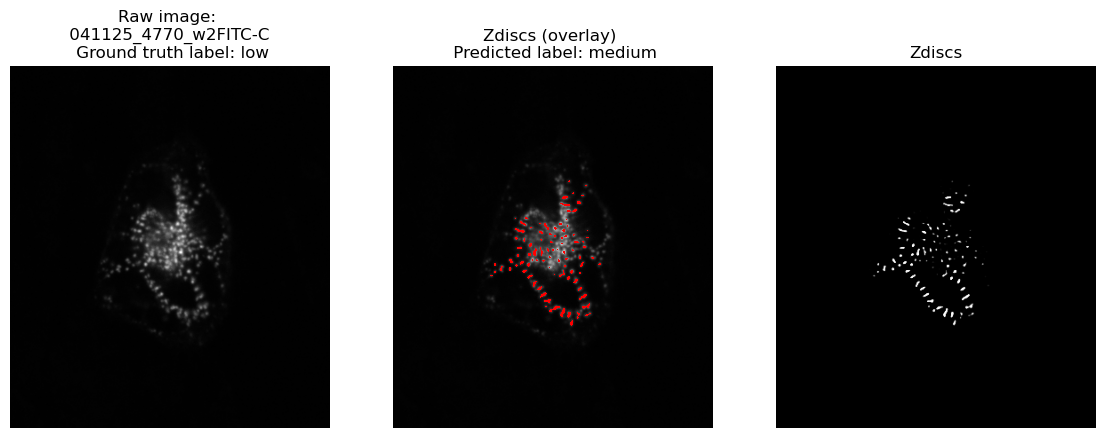

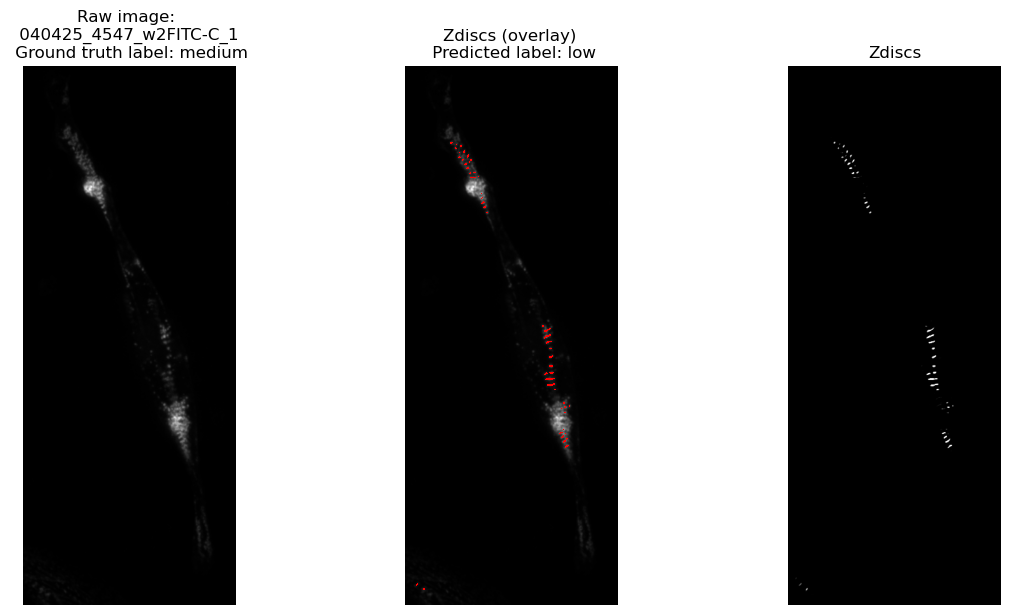

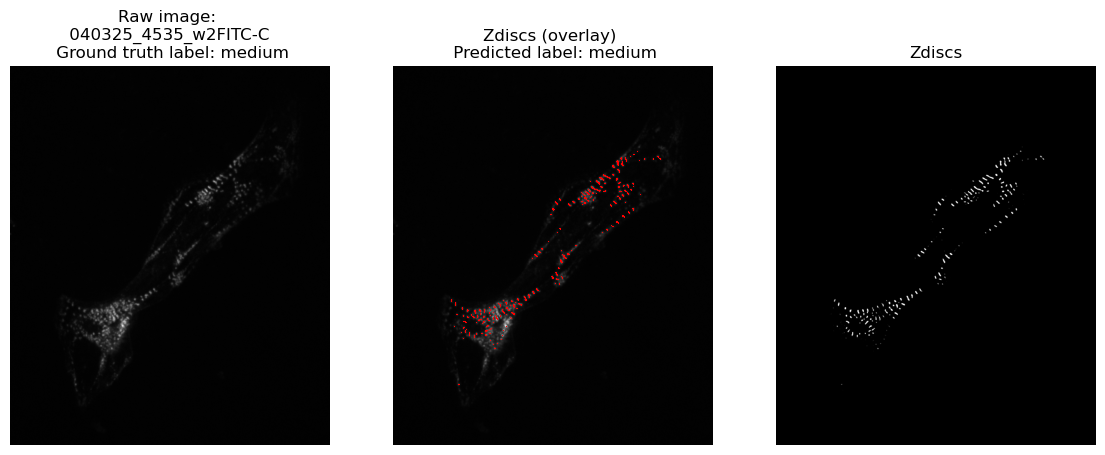

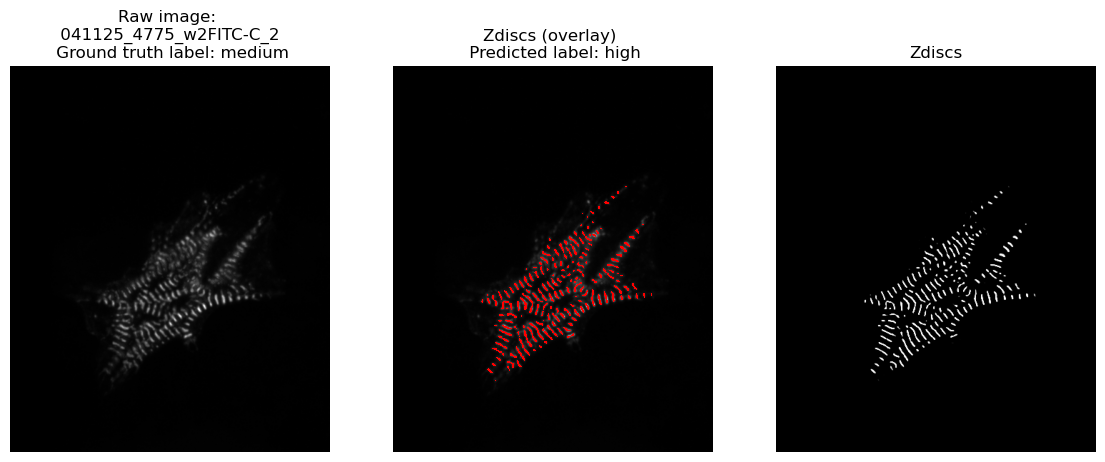

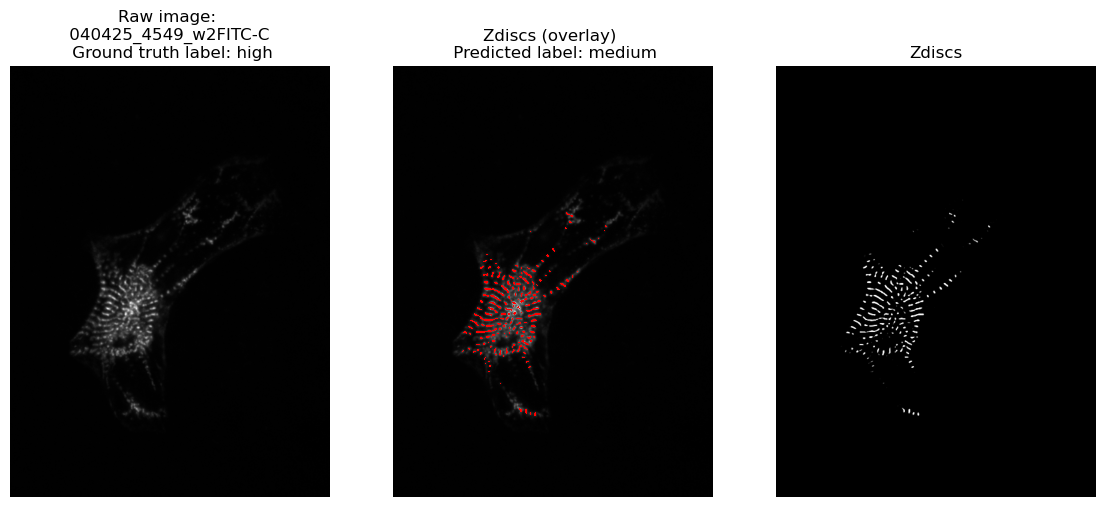

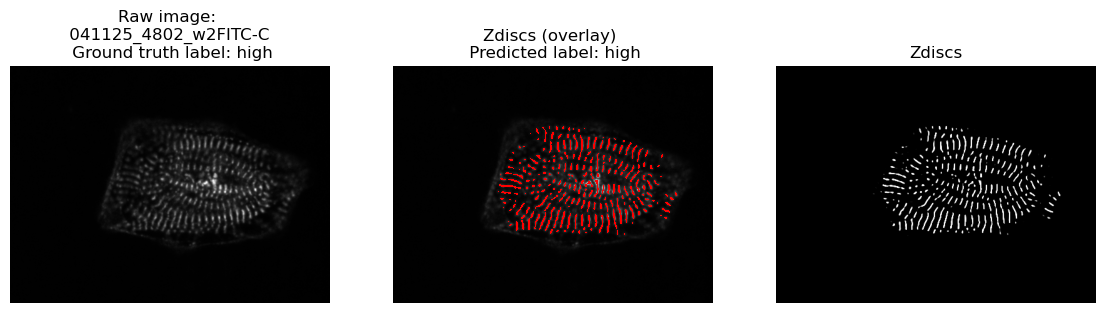

In [8]:
# Grouping test samples by (true_label, pred_label), include empty pairs as well
labelpairs_dict = samples_by_label_pair(test_labels, test_pred, test_names, include_empty=True)

# Picking one random sample ID from each (true, pred) pair
random_samples_dict = pick_random_per_pair(labelpairs_dict, seed = SEED)

# Plotting the chosen sample for each pair (or reporting if none exist)
for pair_key, sample_id in random_samples_dict.items():
    if sample_id:
        plot_gndvspred(pair_key, sample_id, raw_folder_dir)
    else:
        print( f'No samples for {pair_key} key')